# Model Iteration Performance Assessment

## Metrics Chosen

FID (Fréchet Inception Distance) and KID (Kernel Inception Distance) are key metrics for evaluating Generative Adversarial Networks (GANs) by comparing the distributions of real and generated images. They measure both image quality (fidelity) and variety (diversity), with lower scores indicating better, more realistic output.

## Frameworks


In [4]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import os

## Config

In [5]:
MAIN_DIR = r"GAN/outputs"

## Reading Data

In [6]:
dataframes_dict = {}
full_name = {}

for folder in os.listdir(MAIN_DIR):
    if "g7" in folder: continue
    folder_path = os.path.join(MAIN_DIR, folder, "metrics")
    if os.path.isdir(folder_path):
        # extract the two dataframes
        df1 = pd.read_csv(os.path.join(folder_path, "fid_kid_history.csv"))
        df2 = pd.read_csv(os.path.join(folder_path, "training_history.csv"))
        # store in dictionary
        dataframes_dict[folder[:2]] = (df1, df2)
        full_name[folder[:2]] = folder

print(dataframes_dict.keys())
print(full_name.values())

dict_keys(['g0', 'g1', 'g2', 'g3', 'g4', 'g5', 'g6', 'g8', 'g9'])
dict_values(['g0_baseline_instrumented_with_KID', 'g1_more_data', 'g2_discriminator_balancing', 'g3_ema_generator', 'g4_spectralnorm_discriminator', 'g5_full_data_ema_bestfid', 'g6_facecrop_regularized', 'g8_better_discriminator', 'g9_fastgan'])


## Training Loss Evolution

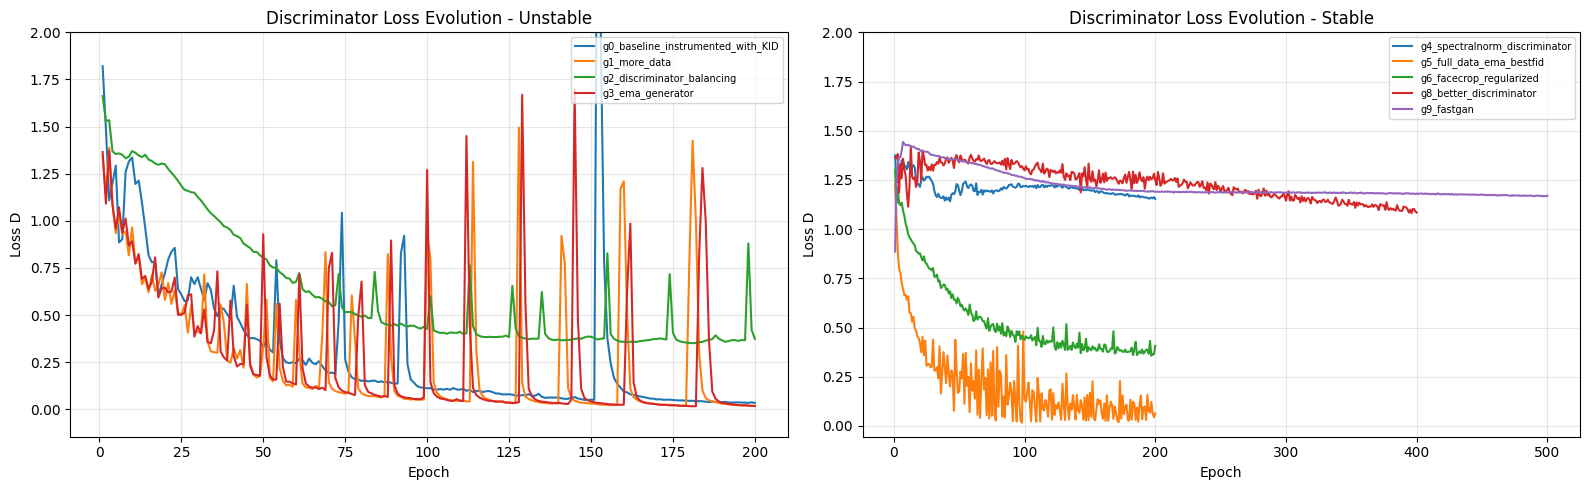

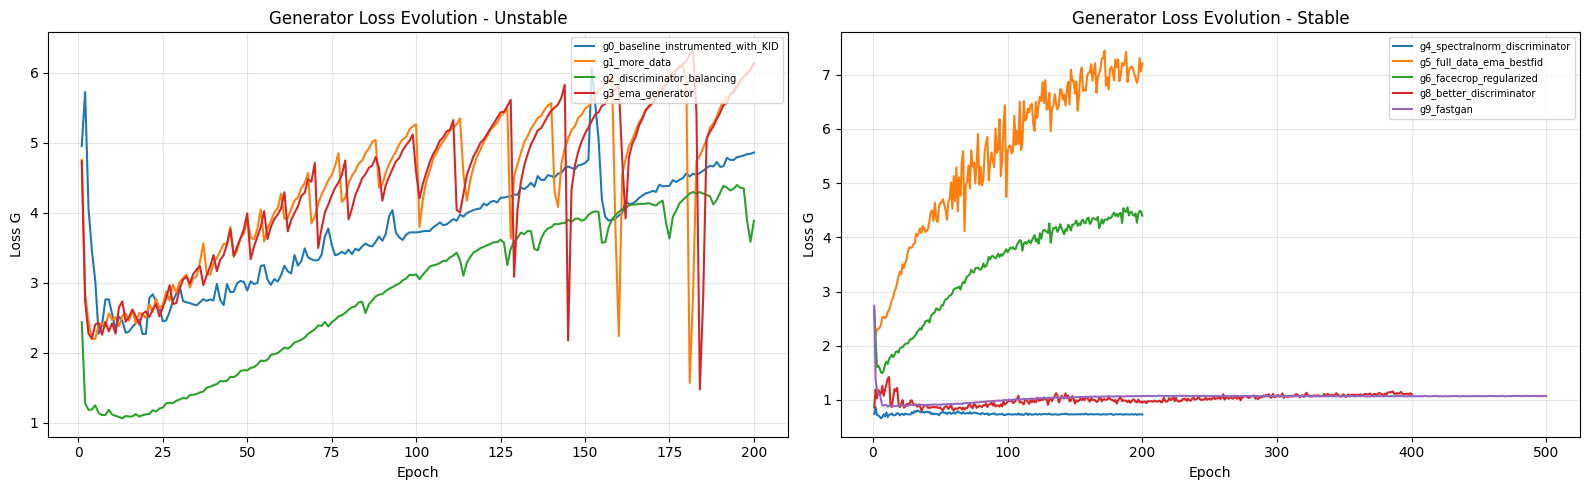

In [7]:
colors = plt.cm.tab10.colors

all_items = list(dataframes_dict.items())
groups = [all_items[:4], all_items[4:]]
subtitles = ["Unstable", "Stable"]

# Discriminator Loss
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, group, subtitle in zip(axes, groups, subtitles):
    for (key, (df_metrics, df_train)), color in zip(group, colors):
        ax.plot(df_train["epoch"], df_train["loss_d"], label=full_name[key], color=color)
    ax.set_title(f"Discriminator Loss Evolution - {subtitle}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss D")
    ax.set_ylim(top=2.0)
    ax.legend(fontsize=7, loc="upper right")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Generator Loss
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, group, subtitle in zip(axes, groups, subtitles):
    for (key, (df_metrics, df_train)), color in zip(group, colors):
        ax.plot(df_train["epoch"], df_train["loss_g"], label=full_name[key], color=color)
    ax.set_title(f"Generator Loss Evolution - {subtitle}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss G")
    ax.legend(fontsize=7, loc="upper right")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Training Stability (Rolling Volatility)

A rolling standard deviation of the discriminator and generator losses over a sliding window of epochs.
High volatility means the training was erratic; low and decreasing volatility means the run settled into a stable equilibrium.
This is a better stability signal than the raw loss curves because it strips out the level and focuses purely on variability.

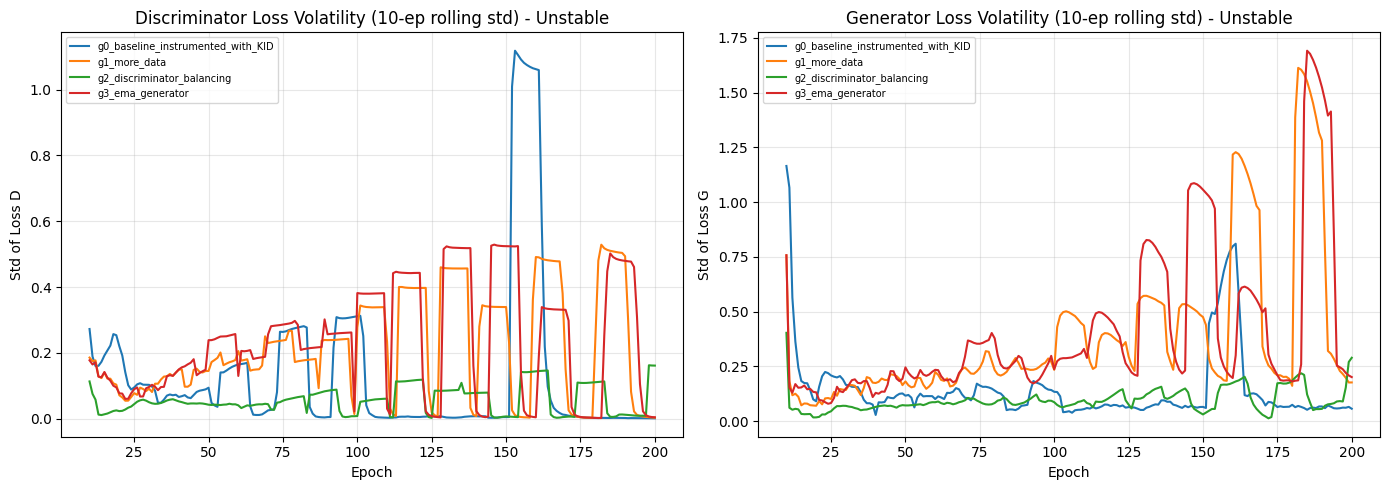

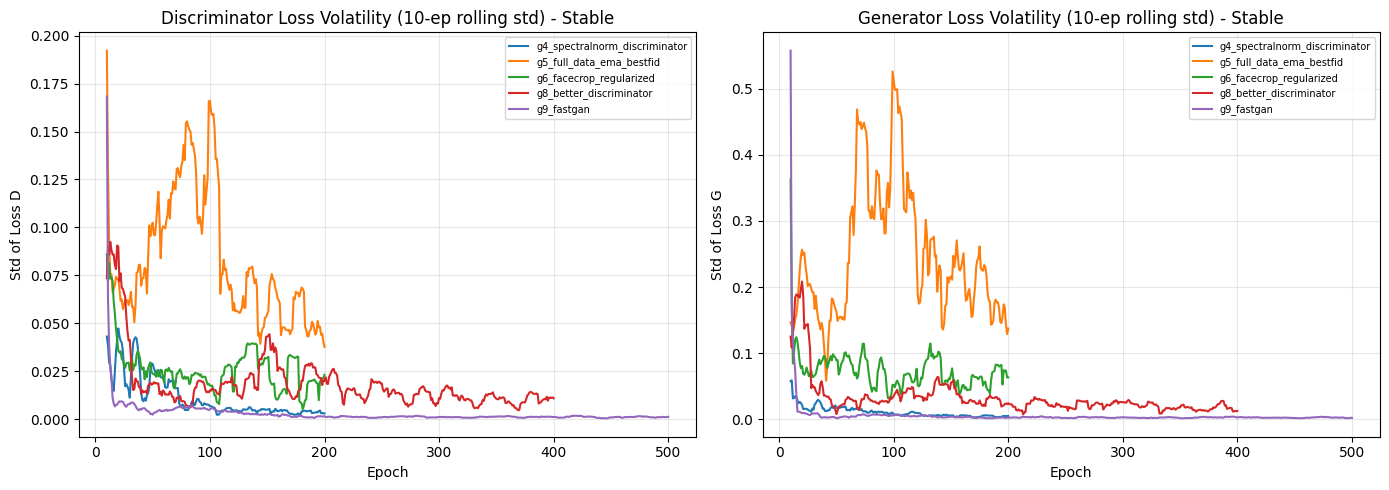

In [8]:
window = 10

all_items = list(dataframes_dict.items())
groups = [all_items[:4], all_items[4:]]
subtitles = ["Unstable", "Stable"]

for group, subtitle in zip(groups, subtitles):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for (key, (df_metrics, df_train)), color in zip(group, colors):
        label = full_name[key]
        roll_d = df_train["loss_d"].rolling(window).std()
        roll_g = df_train["loss_g"].rolling(window).std()
        axes[0].plot(df_train["epoch"], roll_d, label=label, color=color)
        axes[1].plot(df_train["epoch"], roll_g, label=label, color=color)

    axes[0].set_title(f"Discriminator Loss Volatility ({window}-ep rolling std) - {subtitle}")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Std of Loss D")
    axes[0].legend(fontsize=7)
    axes[0].grid(True, alpha=0.3)

    axes[1].set_title(f"Generator Loss Volatility ({window}-ep rolling std) - {subtitle}")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Std of Loss G")
    axes[1].legend(fontsize=7)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## Discriminator-Generator Balance 

These three signals come directly from the discriminator's outputs:

- **D(x)**: discriminator confidence on real images, ideally near 1.0 early on, then converging toward 0.5 as the generator improves.
- **D(G(z)) fake**: discriminator confidence on generated images *before* the generator update, should decrease as the generator gets harder to fool.
- **D(G(z)) gen**: discriminator confidence on generated images *after* the generator update, should increase as the generator learns.

A healthy run shows D(x) staying moderate, D(G(z)) fake low, and D(G(z)) gen gradually rising. Collapse or mode drop often shows up here before it appears in the loss curves.

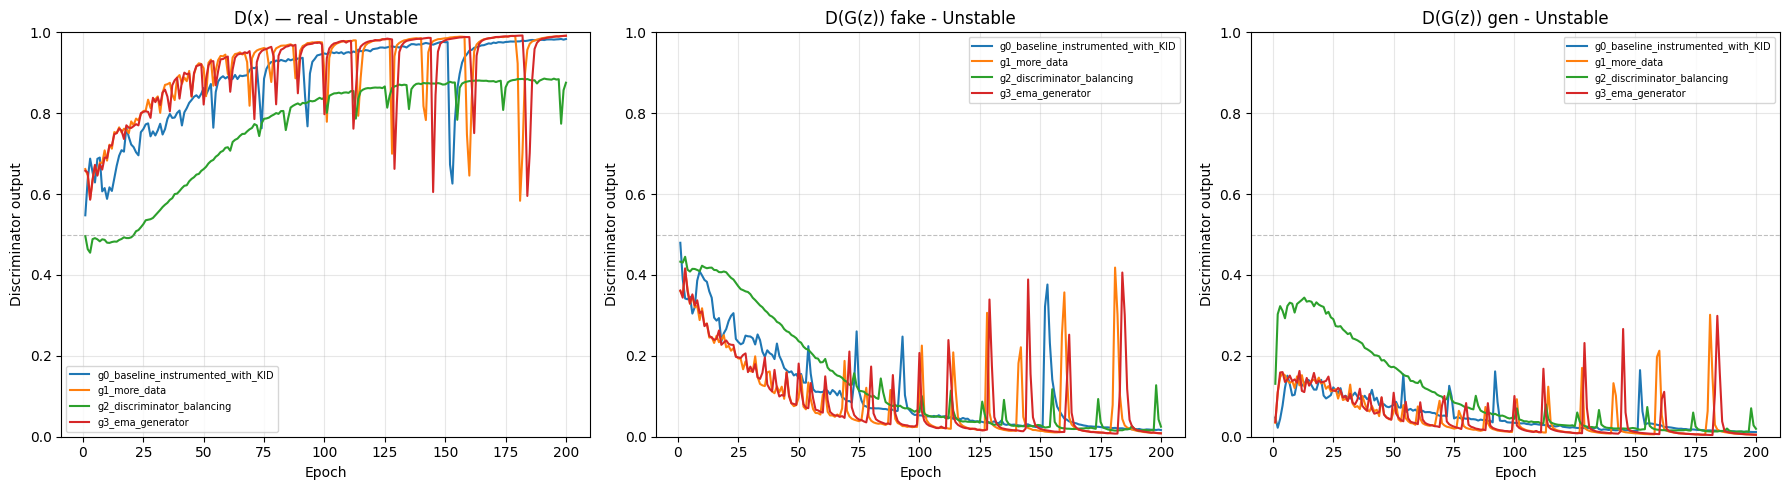

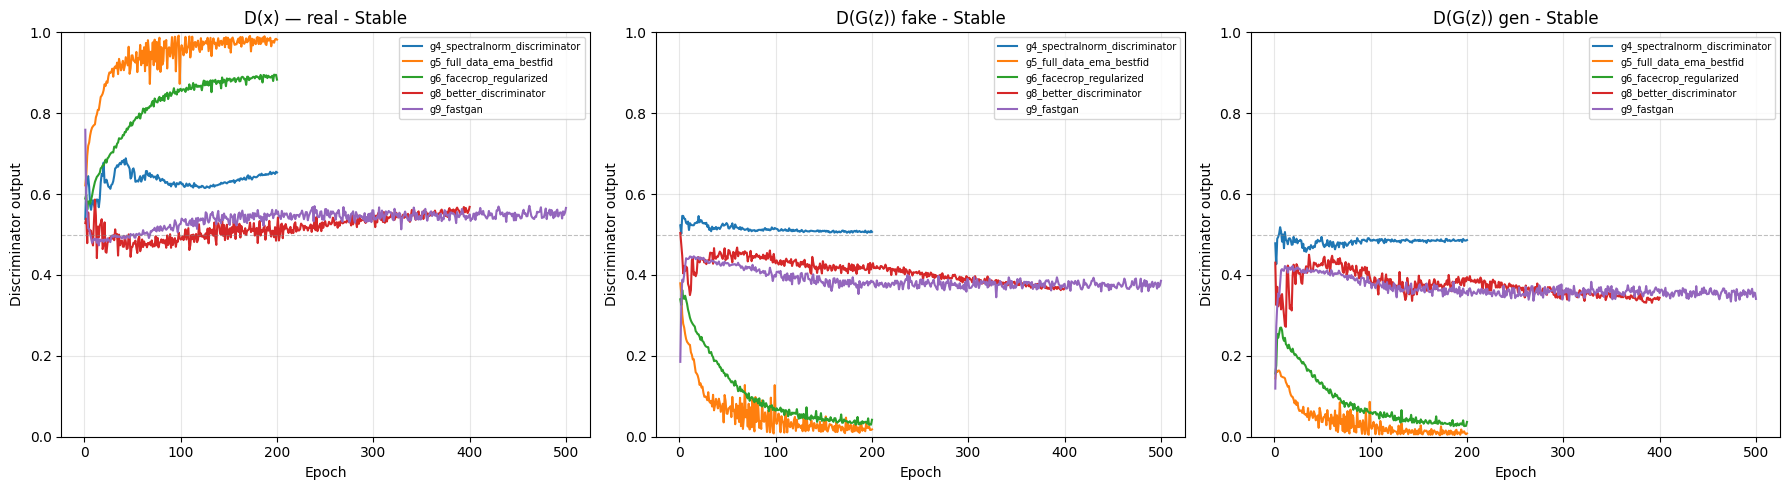

In [9]:
signals = ["D_x", "D_G_z_fake", "D_G_z_gen"]
signal_labels = ["D(x) — real", "D(G(z)) fake", "D(G(z)) gen"]

all_items = list(dataframes_dict.items())
groups = [all_items[:4], all_items[4:]]
subtitles = ["Unstable", "Stable"]

for group, subtitle in zip(groups, subtitles):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for (key, (df_metrics, df_train)), color in zip(group, colors):
        label = full_name[key]
        for ax, signal, sig_label in zip(axes, signals, signal_labels):
            ax.plot(df_train["epoch"], df_train[signal], label=label, color=color)

    for ax, sig_label in zip(axes, signal_labels):
        ax.set_title(f"{sig_label} - {subtitle}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Discriminator output")
        ax.set_ylim(0, 1)
        ax.axhline(0.5, linestyle="--", color="gray", alpha=0.5, linewidth=0.8)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## <span style="color:red"> PROBLEM </span>

Results are indicative of extremely low epochs, might actually benefit from using less data and simply adding more epochs. I can do that tomorrow using the video json saves to showcase that in the end that was what we needed.

## Comparing Performance

### Metric Evolution

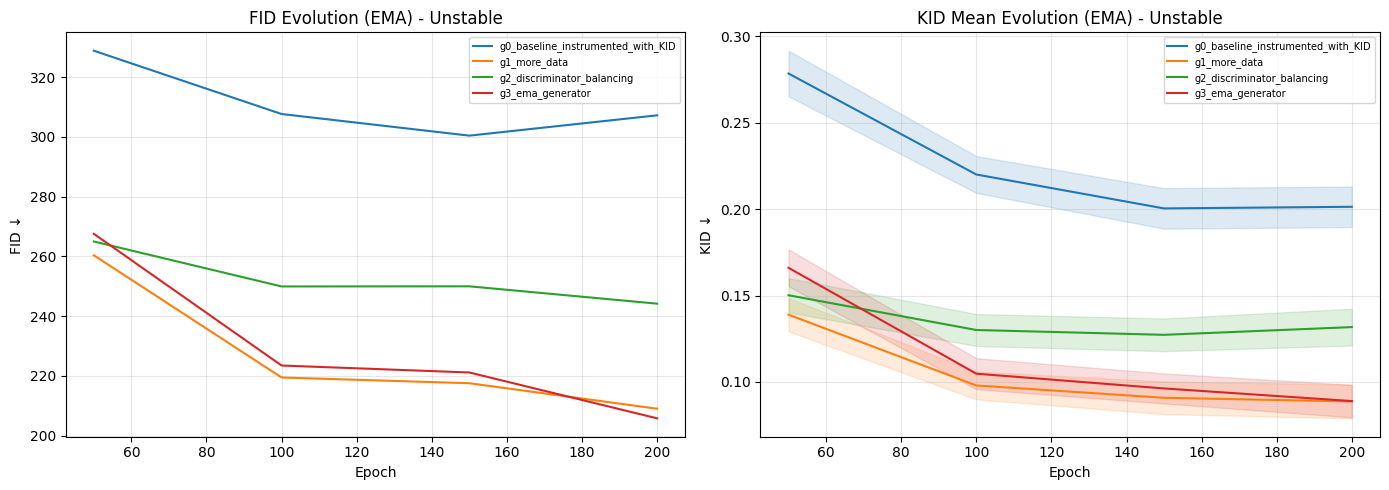

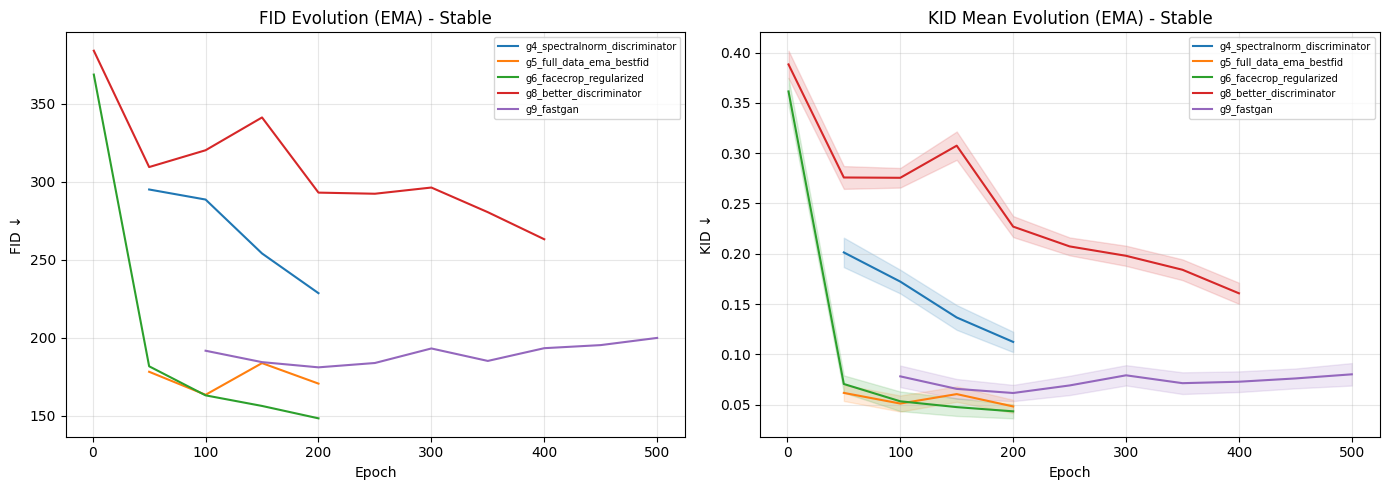

In [10]:
all_items = list(dataframes_dict.items())
groups = [all_items[:4], all_items[4:]]
subtitles = ["Unstable", "Stable"]

for group, subtitle in zip(groups, subtitles):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for (key, (df_metrics, df_train)), color in zip(group, colors):
        label = full_name[key]
        df_ema = df_metrics[df_metrics["evaluated_model"] == "ema"] if "evaluated_model" in df_metrics.columns else df_metrics

        axes[0].plot(df_ema["epoch"], df_ema["fid"], label=label, color=color)
        axes[1].plot(df_ema["epoch"], df_ema["kid_mean"], label=label, color=color)
        axes[1].fill_between(
            df_ema["epoch"],
            df_ema["kid_mean"] - df_ema["kid_std"],
            df_ema["kid_mean"] + df_ema["kid_std"],
            alpha=0.15, color=color
        )

    axes[0].set_title(f"FID Evolution (EMA) - {subtitle}")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("FID ↓")
    axes[0].legend(fontsize=7)
    axes[0].grid(True, alpha=0.3)

    axes[1].set_title(f"KID Mean Evolution (EMA) - {subtitle}")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("KID ↓")
    axes[1].legend(fontsize=7)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

### Model Improvements Assessment

In [11]:
rows = []
for key, (df_metrics, df_train) in dataframes_dict.items():
    df_ema = df_metrics[df_metrics["evaluated_model"] == "ema"] if "evaluated_model" in df_metrics.columns else df_metrics
    last = df_ema.sort_values("epoch").iloc[-1]
    rows.append({
        "run": full_name[key],
        "epoch": int(last["epoch"]),
        "FID": round(last["fid"], 2),
        "KID mean": round(last["kid_mean"], 4),
        "KID std": round(last["kid_std"], 4),
    })

df_summary = pd.DataFrame(rows)


df_summary.style.background_gradient(
    cmap="YlOrRd",
    subset=["FID", "KID mean", "KID std"]
)


,run,epoch,FID,KID mean,KID std
0,g0_baseline_instrumented_with_KID,200,307.240000,0.201300,0.011800
1,g1_more_data,200,208.990000,0.088700,0.009800
2,g2_discriminator_balancing,200,244.180000,0.131700,0.010600
3,g3_ema_generator,200,205.770000,0.088900,0.009400
4,g4_spectralnorm_discriminator,200,228.510000,0.112400,0.010100
5,g5_full_data_ema_bestfid,200,170.490000,0.048300,0.006600
6,g6_facecrop_regularized,200,148.200000,0.043500,0.007000
7,g8_better_discriminator,400,263.120000,0.160700,0.010500
8,g9_fastgan,500,199.800000,0.080300,0.011200


## Key Conclusions

1. Model always benefits from an increase in complexity, and throughout every iteration


## TO-DO

1. Check if more epochs helps
2. Add full explanation of what each implementation does, with research & reasoning to back it!!!
3. Add explanations of low resources and high computation times & strain 